In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import mannwhitneyu as mwu
# import ezodf

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from decimal import Decimal
# from statannot import add_stat_annotation as asa
from tqdm import tqdm 
import io
from Bio.SeqUtils import molecular_weight as calculate_molecular_weight


from scipy.stats import normaltest
from scipy.stats import pearsonr

import sys
sys.path.insert(1, '../../scripts/') # comment out in python script
from human_me.utils.load_environmental_variables import *
prebuild = '/data2/hratch/human_me/prebuild/'

/home/hratch/Projects/human_me/me_env/lib/python3.6/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [8]:
# # parse and compile brenda
# enzymes = open(prebuild + '/brenda_download.txt').read().split(sep = 'RECOMMENDED_NAME')[2:]
# enzymes = [e for e in tqdm(enzymes) if 'Homo sapiens' in e and 'TURNOVER_NUMBER' in e]
# brenda = pd.DataFrame(columns = ['EC-class', 'Protein Number', 'Turnover (s^-1)'])

# error_lines = ['pH', 'hydrolysis', 'comparison', 'F152I,']
# brenda_idx = 0
# counter = 0
# for e in tqdm(enzymes):
#     id_ = e[e.index('ID\t'):].split('\t')[1].split('\n')[0]
#     if 'PROTEIN' in e:
#         e = e.split('\n\n')
#         turnover = [i for i in e if 'TURNOVER_NUMBER' in i][0].split('\n')[1:] # get kcats
#         protein = [i for i in e if 'PROTEIN' in i][0].split('\n')
#         protein = [i.split('\t')[1].split(' Homo sapiens')[0] for i in protein if 'Homo sapiens' in i] # get protein no for human

#         # filter for turnover numbers of human proteins
#         turnover = [i for i in turnover if i.split('\t')[1].split(' ')[0] in protein]
#         if len(turnover)>0:
#             for i in turnover:
#                 comment = i.split('(')
#                 if len(comment)==1 or 'mutant' not in comment[1]: # filter out mutant proteins
#                     vals = i.split('\t')[1].split(' ')
#                     protein_no = vals[0]
#                     if protein_no in protein:
#                         if vals[1] not in error_lines and '-' not in vals[1]:
#                             turnover_ = float(vals[1])
#                         else: 
#                             if '-' in vals[1]: 
#                                 if len(vals[1].split('-')) > 2:
#                                     turnover_ = np.mean([float(i) for i in vals[1].split('-')]) # take avg when a range is provided
#                                 else:
#                                     pass # only one end of range provided
#                             elif vals[1] in error_lines:
#                                 pass # disregard the weird parsed line
#                         brenda.loc[brenda_idx, :] = [id_, protein_no, turnover_]
#                         brenda_idx += 1
    
# brenda['Turnover (s^-1)'] = brenda['Turnover (s^-1)'].astype(float)

# # take average across unique EC-class - Protein No pairs
# brenda = pd.DataFrame(brenda.groupby(['EC-class', 'Protein Number'])['Turnover (s^-1)'].mean())
brenda.to_csv(prebuild + 'processed_brenda_keff.csv')

100%|██████████| 864/864 [00:01<00:00, 566.01it/s]


In [6]:
turn_char = 'Turnover (s^-1)'
k_eff_median = brenda[turn_char].median()
print(k_eff_median)

3.983333333333333


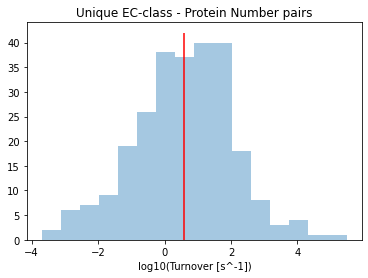

In [11]:
fig, ax = plt.subplots()
sns.distplot(np.log10(brenda[turn_char]), kde = False, ax = ax)
ax.set(xlabel = 'log10(Turnover [s^-1])', title = 'Unique EC-class - Protein Number pairs')
ylim = ax.get_ylim()
ax.vlines(np.log10(k_eff_median), ymin = ylim[0], ymax = ylim[1], color = 'red')
plt.savefig('/data2/hratch/human_me/figures/png/enzyme_turnover_distribution.png')
plt.savefig('/data2/hratch/human_me/figures/pdf/enzyme_turnover_distribution.pdf')

In [20]:
complex_df = pd.read_csv(local_data_path + 'interim/SASA_recon2_2.csv', index_col = 0)

/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551 FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551 FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).


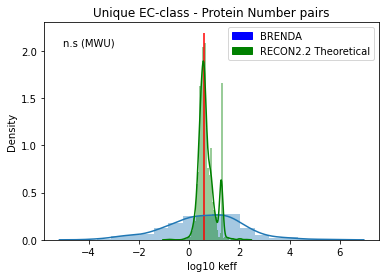

In [38]:
fig, ax = plt.subplots()

sns.distplot(np.log10(brenda[turn_char]), kde = True, ax = ax)
ax.set(xlabel = 'log10(Turnover [s^-1])', title = 'Unique EC-class - Protein Number pairs')
sns.distplot(np.log10(complex_df.drop_duplicates(subset = 'machinery').keff/3600), kde = True, ax = ax, color = 'green')

ylim = ax.get_ylim()
ax.vlines(np.log10(k_eff_median), ymin = ylim[0], ymax = ylim[1], color = 'red')

ax.set(xlabel = 'log10 keff')
ax.annotate('n.s (MWU)', xy = (-5,2.05))

blue_patch = mpatches.Patch(color='blue', label='BRENDA')
green_patch = mpatches.Patch(color='green', label='RECON2.2 Theoretical')
ax.legend(handles=[blue_patch, green_patch])

plt.savefig(local_data_path + 'figures/enzyme_turnover_distribution_v_theoretical.png')
plt.savefig(local_data_path + 'figures/enzyme_turnover_distribution_v_theoretical.pdf')

# Ribosome

In [5]:
import pandas as pd
psim_gold = pd.read_hdf('/data2/hratch/human_me/build/psim_gold.h5')

data_url = 'https://raw.githubusercontent.com/hmbaghdassarian/human_me_data/master/'
build_files_url = data_url + 'build/'

In [117]:
rs = pd.read_csv(build_files_url + 'machinery/small_ribosomal_protein.csv', index_col=None, skiprows=[0])['HGNC ID (gene)'].tolist()
rl = pd.read_csv(build_files_url + 'machinery/large_ribosomal_protein.csv', index_col=None, skiprows=[0])['HGNC ID (gene)'].tolist()
rs = psim_gold[psim_gold.HGNC_ID.isin(rs)]
rl = psim_gold[psim_gold.HGNC_ID.isin(rl)]
rbps = pd.concat([rs,rl])

print('Degradation constants for {} out of {} small RPs are known'.format(rs[rs.ALPHA_P.notna()].shape[0], 
                                                                          rs.shape[0]))

print('Degradation constants for {} out of {} large RPs are known'.format(rl[rl.ALPHA_P.notna()].shape[0], 
                                                                          rl.shape[0]))
print('-------')
print('The median and mean values for small RPs are {:.3f} and {:.3f}'.format(rs.ALPHA_P.median(), 
                                                                     rs.ALPHA_P.mean()))
print('The median and mean values for large RPs are {:.3f} and {:.3f}'.format(rl.ALPHA_P.median(), 
                                                                     rl.ALPHA_P.mean()))
print('The median and mean values for all RPs are {:.3f} and {:.3f}'.format(rbps.ALPHA_P.median(), 
                                                                     rbps.ALPHA_P.mean()))

Degradation constants for 33 out of 34 small RPs are known
Degradation constants for 43 out of 51 large RPs are known
-------
The median and mean values for small RPs are 0.010 and 0.011
The median and mean values for large RPs are 0.010 and 0.011
The median and mean values for all RPs are 0.010 and 0.011


In [118]:
# BioID 112256 (https://doi.org/10.1021/pr800641v)
doherty_rs = pd.DataFrame(columns = ['UNIPROT_ID', 'ALPHA_P'])
doherty_rs['UNIPROT_ID'] = ['P46783', 'Q3T0V4', 'P62277', 'Q56JX8', 'P62263', 'P62841', 'P62244', 
                         'P62249', 'P08708', 'P62269', 'Q32PD5', 'P15880', 'P60866', 'P63220',
                         'P62266', 'P62847', 'P62851', 'P62854', 'P62857', 'P23396', 'Q56JV9', 'P62701',
                         'Q5E988', 'P62753', 'P62081', 'P46781', 'P08865'
                        ]
doherty_rs['ALPHA_P'] = [0.01125,  0.01366,  0.01098,  0.11707, 0.0133,  0.03617,  0.00086, 0.01233,  0.01959,  
                      0.01053,  0.01142, 0.10656, 0.07814, 0.0183,
0.02771, 0.02004, 0.0109, 0.01144, 0.00561, 0.03194, 0.0567, 0.0418,
0.01656, 0.11082, 0.01761, 0.01184, 0.01186]

doherty_rl = pd.DataFrame(columns = ['UNIPROT_ID', 'ALPHA_P'])
doherty_rl['UNIPROT_ID'] = ['Q5E9E6', 'Q96L21', 'P30050', 'P26373', 'Q6NZ55', 'P50914', 'P18621', 'Q07020', 'Q02543', 'P84098', 
                            'P46778', 'P62829', 'P62750', 'P83731' , 'P61254', 'P61353', 'P46779', 'P39023', 
                            'P62899', 'P62910', 'P42766', 'P18077', 'Q9Y3U8', 'P63173', 'P36578', 'P46777', 
                            'Q02878', 'Q8N5Z7', 'P62424', 'P62917', 'Q3T0S6']
doherty_rl['ALPHA_P'] = [0.01426, 0.47065,
0.01049, 0.01461, 0.01527, 0.00581, 0.0365, 0.028, 0.02013 ,
0.116, 0.06075, 0.00625, 0.00481,
0.1113, 0.01325, 0.01631, 0.01323,
0.050, 0.0175, 0.01667, 0.01329, 0.03955, 0.07326, 0.04451 , 0.30588, 0.02669,
0.017, 0.01419, 0.08844, 0.10958, 0.08467]

doherty_rbps = pd.concat([doherty_rs,doherty_rl])

print('The median and mean values for small RPs are {:.3f} and {:.3f}'.format(doherty_rs.ALPHA_P.median(), 
                                                                     doherty_rs.ALPHA_P.mean()))
print('The median and mean values for large RPs are {:.3f} and {:.3f}'.format(doherty_rl.ALPHA_P.median(), 
                                                                     doherty_rl.ALPHA_P.mean()))
print('The median and mean values for all RPs are {:.3f} and {:.3f}'.format(doherty_rbps.ALPHA_P.median(), 
                                                                     doherty_rbps.ALPHA_P.mean()))




The median and mean values for small RPs are 0.017 and 0.031
The median and mean values for large RPs are 0.020 and 0.060
The median and mean values for all RPs are 0.018 and 0.046


In [119]:
dfs = [rs, rl, doherty_rs, doherty_rl]

for df in dfs:
    df.sort_values(by = 'UNIPROT_ID', inplace = True)
    df.set_index('UNIPROT_ID', drop = False, inplace = True)

rbps = pd.concat([rs,rl])
doherty_rbps = pd.concat([doherty_rs,doherty_rl])

/home/hratch/Projects/human_me/me_env/lib/python3.6/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


/home/hratch/Projects/human_me/me_env/lib/python3.6/site-packages/pandas/core/frame.py:4308: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


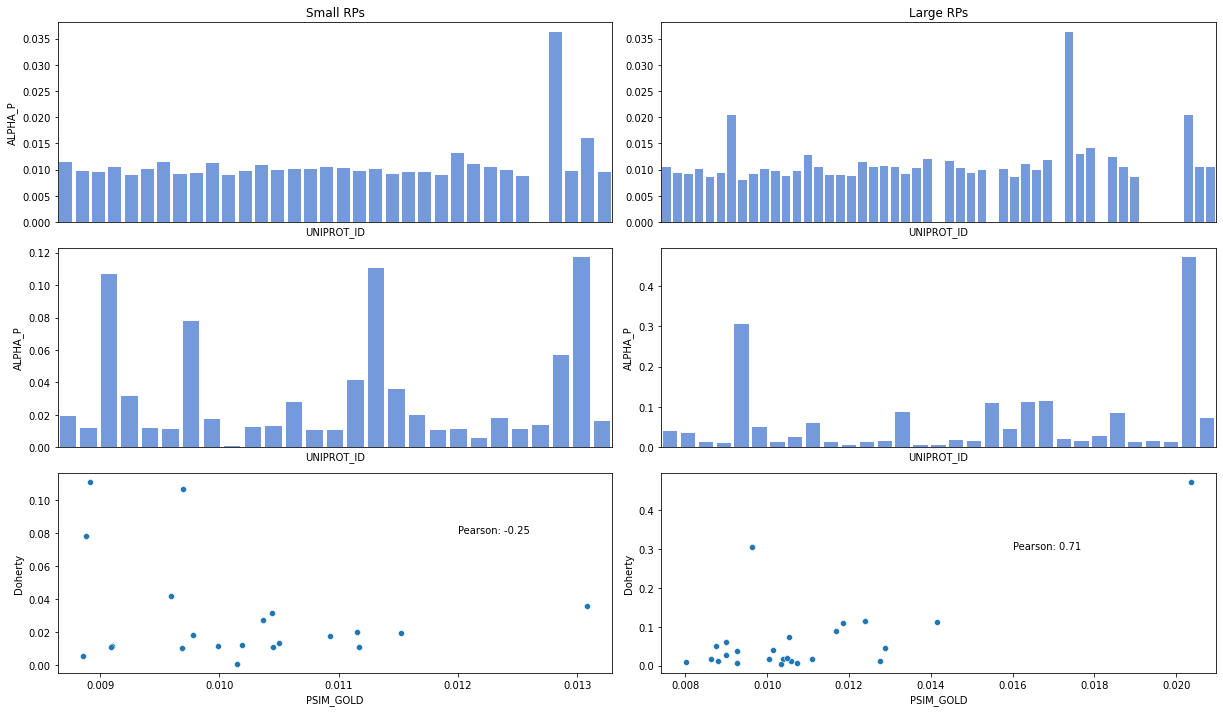

In [120]:
fig, ax = plt.subplots(ncols=2, nrows = 3, figsize = (17,10))

g1 = sns.barplot(data = rs, x = 'UNIPROT_ID', y = 'ALPHA_P', ax = ax[0, 0], color = 'cornflowerblue')
g2 = sns.barplot(data = rl, x = 'UNIPROT_ID', y = 'ALPHA_P', ax = ax[0,1], color = 'cornflowerblue')

titles = ['Small RPs', 'Large RPs']
ax[0,1].set_ylabel('')
    
g3 = sns.barplot(data = doherty_rs, x = 'UNIPROT_ID', y = 'ALPHA_P', ax = ax[1, 0], color = 'cornflowerblue')
g4 = sns.barplot(data = doherty_rl, x = 'UNIPROT_ID', y = 'ALPHA_P', ax = ax[1,1], color = 'cornflowerblue')

for df in [rs, rl]:
    df.rename(columns = {'ALPHA_P': 'PSIM_GOLD'}, inplace = True)
for df in [doherty_rs, doherty_rl]:
    df.rename(columns = {'ALPHA_P': 'Doherty'}, inplace = True)
rs_both = pd.concat([doherty_rs, rs], axis = 1)
rl_both = pd.concat([doherty_rl, rl], axis = 1)

rs_both_filtered = rs_both[rs_both.PSIM_GOLD.notna() & rs_both.Doherty.notna()]
rs_r = pearsonr(rs_both_filtered.PSIM_GOLD, rs_both_filtered.Doherty)[0]

rl_both_filtered = rl_both[rl_both.PSIM_GOLD.notna() & rl_both.Doherty.notna()]
rl_r = pearsonr(rl_both_filtered.PSIM_GOLD, rl_both_filtered.Doherty)[0]

g5 = sns.scatterplot(data = rs_both, x = 'PSIM_GOLD', y = 'Doherty', ax = ax[2, 0])
g6 = sns.scatterplot(data = rl_both, x = 'PSIM_GOLD', y = 'Doherty', ax = ax[2, 1])
ax[2,0].annotate('Pearson: {:.2f}'.format(rs_r), xy = (0.012, 0.08))
ax[2,1].annotate('Pearson: {:.2f}'.format(rl_r), xy = (0.016, 0.3))



for i in range(2):
    ax[0, i].set_title(titles[i])
    for j in range(2):
        ax[j, i].set_xticks([])

plt.tight_layout()

for ext in ['.png', '.svg', '.pdf']:
    plt.savefig('/data2/hratch/human_me/' + 'figures/ribosome_halflives' + ext)